# Text Preprocessing

Processing the text of the airlines dataframe to remove mentions, hashtags, emojis, acronyms etc. to ensure the data is ready for tokenization step

## Importing Packages

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import emoji
import contractions

sns.set_theme(style='ticks')


## Load Dataset

In [41]:
airlines = pd.read_csv(r'C:\Users\karina mehta\UVA class\Semester 2\Text As Data\us_airlines_dataset\Tweets.csv')
airlines.head(1)


             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                           1.0   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   

  airline_sentiment_gold     name negativereason_gold  retweet_count  \
0                    NaN  cairdin                 NaN              0   

                                  text tweet_coord              tweet_created  \
0  @VirginAmerica What @dhepburn said.         NaN  2015-02-24 11:35:52 -0800   

  tweet_location               user_timezone  
0            NaN  Eastern Time (US & Canada)  

In [42]:
airline_table = airlines[['airline','retweet_count','text','tweet_created','tweet_location','user_timezone']].copy()

In [43]:
airline_table.head(1)

          airline  retweet_count                                 text  \
0  Virgin America              0  @VirginAmerica What @dhepburn said.   

               tweet_created tweet_location               user_timezone  
0  2015-02-24 11:35:52 -0800            NaN  Eastern Time (US & Canada)  

## Handling Datatype

In [44]:
airline_table.dtypes
airline_table['tweet_created'] = pd.to_datetime(airline_table['tweet_created'], utc=True)
airline_table.dtypes

airline                        object
retweet_count                   int64
text                           object
tweet_created     datetime64[ns, UTC]
tweet_location                 object
user_timezone                  object
dtype: object

In [45]:
#Creating Day and Time columns
airline_table['day'] = airline_table['tweet_created'].dt.day
airline_table['hour'] = airline_table['tweet_created'].dt.hour
airline_table['day_of_week'] = airline_table['tweet_created'].dt.dayofweek
airline_table['day_name'] = airline_table['tweet_created'].dt.day_name()
airline_table.head()

          airline  retweet_count  \
0  Virgin America              0   
1  Virgin America              0   
2  Virgin America              0   
3  Virgin America              0   
4  Virgin America              0   

                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

              tweet_created tweet_location               user_timezone  day  \
0 2015-02-24 19:35:52+00:00            NaN  Eastern Time (US & Canada)   24   
1 2015-02-24 19:15:59+00:00            NaN  Pacific Time (US & Canada)   24   
2 2015-02-24 19:15:48+00:00      Lets Play  Central Time (US & Canada)   24   
3 2015-02-24 19:15:36+00:00            NaN  Pacific Time (US & Canada)   24   
4 2015-02-24 19:14:45+00:00            NaN  Pacific

## Removing Mentions, URLS and hashtags from text

In [46]:
def extract_and_clean(text):
    # Extract before removing
    mentions  = re.findall(r'@\w+', text)
    hashtags  = re.findall(r'#\w+', text)

    # Clean text
    text = re.sub(r'@\w+', '', text)                    # remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'#(\w+)', r'\1', text)               # remove # keep word
    text = re.sub(r'&amp;', '&', text)                  # fix HTML entities
    text = re.sub(r'<.*?>', '', text)                   # fix HTML tags
    text = re.sub(r'\s+', ' ', text)                    # extra whitespace
    text = contractions.fix(text)                       # fix contractions
    text = emoji.demojize(text)                         # convert emojis to text
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)          # remove excessive repetition
    text = text.strip().lower()

    return {
        'cleaned_text' : text,
        'mentions'     : mentions if mentions else None,
        'hashtags'     : hashtags if hashtags else None,
    }

In [47]:
extracted = airline_table['text'].apply(extract_and_clean)
airline_table['cleaned_text'] = extracted.apply(lambda x: x['cleaned_text'])
airline_table['mentions']     = extracted.apply(lambda x: x['mentions'])
airline_table['hashtags']     = extracted.apply(lambda x: x['hashtags'])

## Expansion

#### Chat Words
Expanding acronyms into full length words

In [48]:
df_txt  = pd.read_csv('slang/slang.txt', sep='\t', names=['acronym', 'expansion'])  # dilmiter = "\t"


In [49]:
chat_words = {k.lower(): v.lower() for k, v in df_txt.set_index('acronym')['expansion'].to_dict().items()}

In [50]:
def chat_conversion(text):
    new_text = []
    for w in text.split():
        if w in chat_words:
            new_text.append(chat_words[w])
        else:
            new_text.append(w)
    return ' '.join(new_text)

In [51]:
airline_table['cleaned_text'] = airline_table['cleaned_text'].apply(chat_conversion)

In [52]:
airline_table['text'][3]

'@VirginAmerica it\'s really aggressive to blast obnoxious "entertainment" in your guests\' faces &amp; they have little recourse'

In [53]:
airline_clean = airline_table[['airline','mentions','hashtags','tweet_created','day','hour','day_of_week','day_name','retweet_count','cleaned_text']].copy()
airline_clean.head()

          airline                     mentions hashtags  \
0  Virgin America  [@VirginAmerica, @dhepburn]     None   
1  Virgin America             [@VirginAmerica]     None   
2  Virgin America             [@VirginAmerica]     None   
3  Virgin America             [@VirginAmerica]     None   
4  Virgin America             [@VirginAmerica]     None   

              tweet_created  day  hour  day_of_week day_name  retweet_count  \
0 2015-02-24 19:35:52+00:00   24    19            1  Tuesday              0   
1 2015-02-24 19:15:59+00:00   24    19            1  Tuesday              0   
2 2015-02-24 19:15:48+00:00   24    19            1  Tuesday              0   
3 2015-02-24 19:15:36+00:00   24    19            1  Tuesday              0   
4 2015-02-24 19:14:45+00:00   24    19            1  Tuesday              0   

                                        cleaned_text  
0                                         what said.  
1  plus you have added commercials time out the e...  
2  i 

#### Extracting Features

In [54]:
airline_clean['str_len'] = airline_clean.cleaned_text.str.len()
airline_clean.str_len.describe()

count    14640.000000
mean       110.176503
std         48.707082
min          1.000000
25%         74.000000
50%        118.000000
75%        145.000000
max        602.000000
Name: str_len, dtype: float64

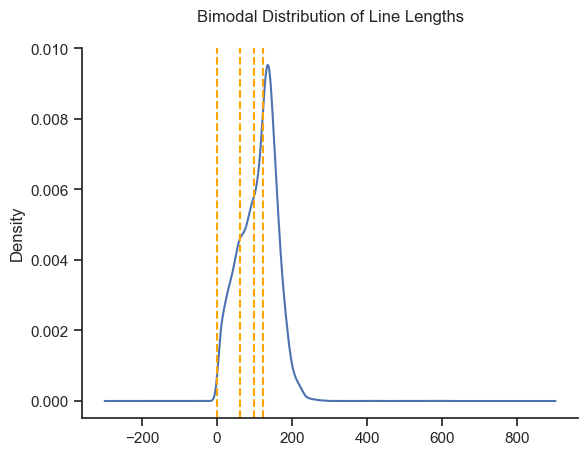

In [55]:
ax = airline_clean['str_len'].plot.kde()
ax.axvline(1, c='orange', ls='--')
ax.axvline(61, c='orange', ls='--')
ax.axvline(98, c='orange', ls='--')
ax.axvline(122, c='orange', ls='--')
plt.title("Bimodal Distribution of Line Lengths", y=1.05)
sns.despine()
plt.show()

#### Saving Clean Dataset

In [56]:
airline_clean.head()

          airline                     mentions hashtags  \
0  Virgin America  [@VirginAmerica, @dhepburn]     None   
1  Virgin America             [@VirginAmerica]     None   
2  Virgin America             [@VirginAmerica]     None   
3  Virgin America             [@VirginAmerica]     None   
4  Virgin America             [@VirginAmerica]     None   

              tweet_created  day  hour  day_of_week day_name  retweet_count  \
0 2015-02-24 19:35:52+00:00   24    19            1  Tuesday              0   
1 2015-02-24 19:15:59+00:00   24    19            1  Tuesday              0   
2 2015-02-24 19:15:48+00:00   24    19            1  Tuesday              0   
3 2015-02-24 19:15:36+00:00   24    19            1  Tuesday              0   
4 2015-02-24 19:14:45+00:00   24    19            1  Tuesday              0   

                                        cleaned_text  str_len  
0                                         what said.       10  
1  plus you have added commercials time ou

In [57]:
airline_clean.to_parquet('airline_clean.parquet', engine='pyarrow', index=False)